In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.inspection import DecisionBoundaryDisplay
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score, ConfusionMatrixDisplay
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from scipy.stats import randint
from sklearn.tree import export_graphviz
from IPython.display import Image
import tensorflow as tf
from tensorflow import keras
import seaborn as sns

In [ ]:
#df_train = pd.read_csv('/content/Dataset_Conjunt_Normalitzat_300m_v15.txt', header=None)
#df_test = pd.read_csv('/content/Dataset_Conjunt_Normalitzat_156m_test_V15.txt', header=None) #156m
df_Conjunt = pd.read_csv('/content/Train_Test_Normalitzat_Conjunt_V2.txt',header=None)

In [ ]:
df_train, df_test = train_test_split(df_Conjunt, test_size=0.15, random_state=52)

ta
FE_Train = df_train.iloc[:, 0:7]
Etiqueta_Train = df_train.iloc[:, 7]

FE_Test = df_test.iloc[:, 0:7]
Etiqueta_Test = df_test.iloc[:, 7]

print(f"Registres Train: {len(df_train)} | Registres Test: {len(df_test)}")

Registros Train: 2170 | Registros Test: 383


In [ ]:
#FE_Train = df_train.iloc[:, 0:7]
#Etiqueta_Train = df_train.iloc[:, 7]
#FE_Test = df_test.iloc[:, 0:7]
#Etiqueta_Test = df_test.iloc[:, 7]

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Definició del model (3 neurones a la sortida per a 3 classes)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(32, activation="relu", input_shape=[FE_Train.shape[1]]),
    tf.keras.layers.Dense(3)
])

model.compile(
    optimizer='adam',
    metrics=['accuracy'],
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True)
)


model.fit(FE_Train, Etiqueta_Train, epochs=100, verbose=0)


test_loss, test_acc = model.evaluate(FE_Test, Etiqueta_Test, verbose=2)


probability_model = tf.keras.Sequential([model, tf.keras.layers.Softmax()])
predictions = pd.DataFrame(probability_model.predict(FE_Test), index=FE_Test.index)


r = predictions.idxmax(axis=1) # Agafa la columna amb més probabilitat (0, 1 o 2)
# Com que les etiquetes són 0, 1, 2, mirem on NO coincideixen
errors = (r != Etiqueta_Test).sum()
total = len(Etiqueta_Test)

print(f"Nombre d'errades: {errors}")
print(f"Percentatge d'encert: {100 * (1 - errors/total):.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


12/12 - 0s - 25ms/step - accuracy: 0.8956 - loss: 0.2819
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Nombre d'errades: 40
Percentatge d'encert: 89.56%


In [ ]:
#rf_model.fit(FE_Train, Etiqueta_Train)
#y_pred = rf_model.predict(FE_Test)

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report

noms_classes = ["Repòs", "Gest1", "Gest2"]

y_pred = np.argmax(predictions.values, axis=1)

print(f"Precisió Global: {accuracy_score(Etiqueta_Test, y_pred):.2f}")

print(classification_report(Etiqueta_Test, y_pred, target_names=noms_classes))

Precisió Global: 0.90
              precision    recall  f1-score   support

       Repos       0.94      0.91      0.93       129
       Gest1       0.84      0.93      0.89       117
       Gest2       0.91      0.85      0.88       137

    accuracy                           0.90       383
   macro avg       0.90      0.90      0.90       383
weighted avg       0.90      0.90      0.90       383



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn import metrics

# Usamos 'average' para manejar los 3 movimientos
accuracy = accuracy_score(Etiqueta_Test, y_pred)
precision = precision_score(Etiqueta_Test, y_pred, average='weighted')
recall = recall_score(Etiqueta_Test, y_pred, average='weighted')

print(f"Accuracy : {accuracy:.3f}")
print(f"Precisió: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print("F1-Score:", metrics.f1_score(Etiqueta_Test, y_pred, average='weighted'))

Accuracy (Precisión Global): 0.896
Precision (Calidad de la predicción): 0.898
Recall (Capacidad de detección): 0.896
F1-Score: 0.8955895163574292


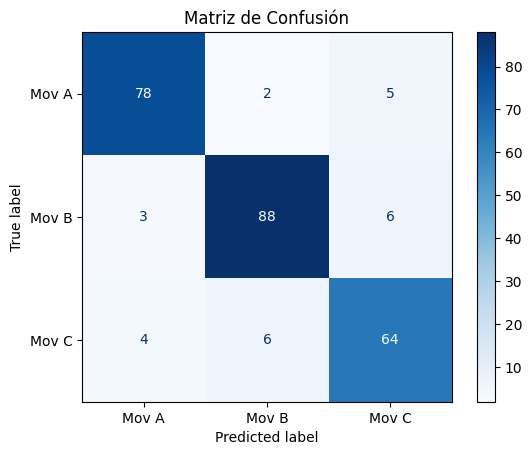

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Generar la matriz
cm = confusion_matrix(Etiqueta_Test, y_pred)

# Visualizarla de forma elegante
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Mov A', 'Mov B', 'Mov C'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriu de Confusió")
plt.show()

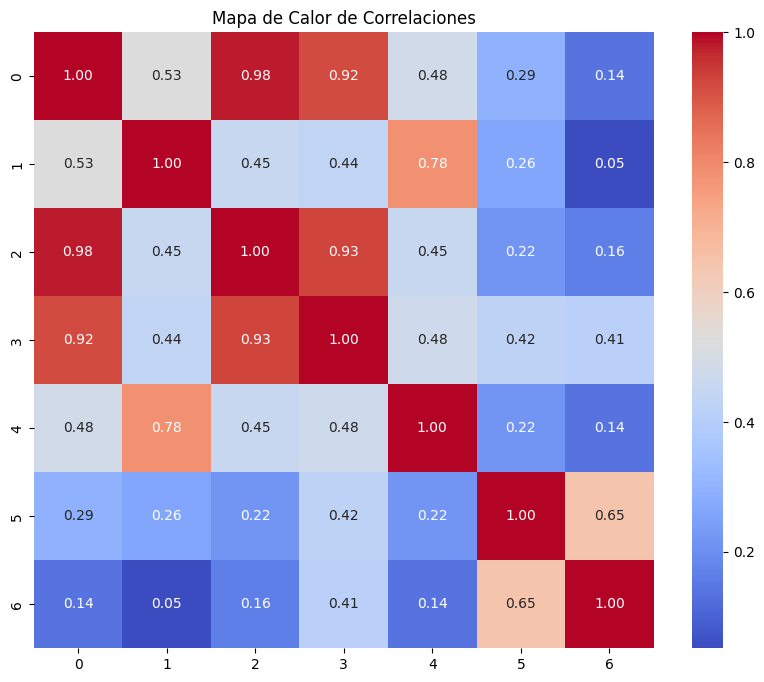

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Ahora ya no dará NameError
plt.figure(figsize=(10, 8))
correlation_matrix = FE_Train.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Mapa de Calor de Correlacions")
plt.show()

In [ ]:
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import cross_val_score
import tensorflow as tf

# Creem una funció que retorni el teu model compilat
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(32, activation="relu", input_shape=[FE_Train.shape[1]]),
        tf.keras.layers.Dense(3) # Recorda: 3 neurones per a 3 gestos
    ])
    model.compile(
        optimizer='adam',
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        metrics=['accuracy']
    )
    return model

# "Embolcallem" el model de Keras perquè sembli un model de Scikit-Learn
clf_keras = KerasClassifier(model=create_model, epochs=100, batch_size=32, verbose=0)

# 2. Executar la Cross Validation
# cv=5 vol dir que dividirem les dades en 5 blocs
scores = cross_val_score(clf_keras, FE_Train, Etiqueta_Train, cv=5)

print(f"Precisió mitjana: {scores.mean()*100:.2f}%")
print(f"Variabilitat: +/- {scores.std() * 2 * 100:.2f}%")

AttributeError: 'super' object has no attribute '__sklearn_tags__'